# LLM Request Trace Analysis (MOONCAKE Dataset Sample)

This notebook analyzes a sample of the LLM request trace data, similar to the workloads described in the MOONCAKE paper. We'll look at:

*   Basic request statistics (rate, duration)
*   Input and Output token length distributions
*   Request arrival patterns (Inter-Arrival Time)
*   Potential for KVCache reuse based on hash IDs

**Note:** This uses a small sample file (`trace_sample.jsonl`). For representative results, run this on the full trace files provided in the [Mooncake GitHub repository](https://github.com/kvcache-ai/Mooncake).

## 1. Setup

Import necessary libraries and define configuration.

In [1]:
import json
import pandas as pd
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import os
import sys

cwd = os.getcwd()
target_dir_rel = os.path.join('..', 'plots', 'akasha')
target_dir_abs = os.path.abspath(os.path.join(cwd, target_dir_rel))

if target_dir_abs not in sys.path:
    sys.path.insert(0, target_dir_abs)

from constants import *

# --- Configuration ---
trace_file = '../data/processed_traces/toolagent_trace.jsonl'
# Block size used for hashing, from Appendix A of the MOONCAKE paper
BLOCK_SIZE = 512

os.makedirs("output", exist_ok=True)

## 2. Load Data

Load the `.jsonl` trace file into a pandas DataFrame.

In [2]:
df = pd.read_json(trace_file, lines=True)

## 3. Data Exploration & Preprocessing

Calculate derived columns needed for analysis.

In [3]:
if not df.empty:
    # Calculate Inter-Arrival Time (IAT) in milliseconds
    df['iat_ms'] = df['timestamp'].diff()
    # First request has no IAT - fill with 0 or NaN
    df['iat_ms'] = df['iat_ms'].fillna(0)

    # Calculate total tokens
    df['total_tokens'] = df['input_length'] + df['output_length']

    # Number of hash blocks per request
    df['num_hash_blocks'] = df['hash_ids'].apply(len)
    # Approx input length based on blocks, for sanity check
    df['approx_input_from_blocks'] = df['num_hash_blocks'] * BLOCK_SIZE

    # --- For Cache Analysis ---
    # Shift hash_ids to compare with previous request
    df['prev_hash_ids'] = df['hash_ids'].shift(1)
    # Fill NaN for the first row's prev_hash_ids with an empty list
    df['prev_hash_ids'] = df['prev_hash_ids'].apply(lambda x: x if isinstance(x, list) else [])

    # Function to calculate prefix match length
    def get_prefix_match_len(current_hashes, prev_hashes):
        if not prev_hashes or not current_hashes:
            return 0
        match_len = 0
        # Ensure elements are comparable if loaded directly from JSON
        min_len = min(len(current_hashes), len(prev_hashes))
        for i in range(min_len):
            if current_hashes[i] == prev_hashes[i]:
                match_len += 1
            else:
                break
        return match_len

    # Calculate prefix match (in blocks and approx tokens)
    df['prefix_match_blocks'] = df.apply(lambda row: get_prefix_match_len(row['hash_ids'], row['prev_hash_ids']), axis=1)
    df['prefix_match_tokens'] = df['prefix_match_blocks'] * BLOCK_SIZE
else:
    print("DataFrame is empty, skipping preprocessing.")

# Display first few rows with new columns
df.head()

,timestamp,input_length,output_length,hash_ids,iat_ms,total_tokens,num_hash_blocks,approx_input_from_blocks,prev_hash_ids,prefix_match_blocks,prefix_match_tokens
0,0,6758,500,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]",0.0,7258,14,7168,[],0,0
1,0,7322,490,"[0, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24...",0.0,7812,15,7680,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]",1,512
2,0,7236,794,"[0, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38...",0.0,8030,15,7680,"[0, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24...",1,512
3,0,2290,316,"[0, 42, 43, 44, 45]",0.0,2606,5,2560,"[0, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38...",1,512
4,0,9013,3,"[46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 5...",0.0,9016,18,9216,"[0, 42, 43, 44, 45]",0,0


## 4. Analysis

Calculate and display key statistics.

### 4.1 Basic Statistics

In [4]:
if not df.empty:
    num_requests = len(df)
    total_duration_ms = df['timestamp'].max() - df['timestamp'].min() if num_requests > 1 else 0
    # Avoid division by zero if duration is 0 or only one request
    avg_request_rate_rps = (num_requests / (total_duration_ms / 1000.0)) if total_duration_ms > 0 else float('inf') if num_requests > 0 else 0

    print("--- Basic Statistics ---")
    print(f"Total requests: {num_requests}")
    print(f"Trace duration (ms): {total_duration_ms:.2f}")
    print(f"Average request rate (req/sec): {avg_request_rate_rps:.2f}")
    print("-" * 25)
else:
    print("DataFrame empty, no basic stats.")

--- Basic Statistics ---
Total requests: 23608
Trace duration (ms): 3536999.00
Average request rate (req/sec): 6.67
-------------------------


### 4.2 Token Length Analysis

Examine the distribution of input, output, and total tokens per request. Long input lengths are characteristic of the workloads targeted by MOONCAKE.

In [5]:
if not df.empty:
    print("--- Token Length Statistics ---")
    print("Input Length:")
    print(df['input_length'].describe().to_string())
    print("\nOutput Length:")
    print(df['output_length'].describe().to_string())
    print("\nTotal Tokens (Input + Output):")
    print(df['total_tokens'].describe().to_string())
    print("\nSanity check: Input Length vs Approx from Blocks:")
    print(df[['input_length', 'approx_input_from_blocks']].head())
    diff = (df['input_length'] - df['approx_input_from_blocks']).abs().mean()
    print(f"\nMean absolute difference: {diff:.2f}") # Check how close they are
    print("-" * 25)
else:
     print("DataFrame empty, no token stats.")

--- Token Length Statistics ---
Input Length:
count     23608.000000
mean       8596.242121
std       11002.997946
min         891.000000
25%        3230.000000
50%        6346.000000
75%        7472.000000
max      126195.000000

Output Length:
count    23608.000000
mean       182.133895
std        242.281174
min          1.000000
25%         13.000000
50%         30.000000
75%        356.000000
max       2000.000000

Total Tokens (Input + Output):
count     23608.000000
mean       8778.376017
std       11070.483000
min         895.000000
25%        3333.000000
50%        6403.000000
75%        7566.000000
max      126527.000000

Sanity check: Input Length vs Approx from Blocks:
   input_length  approx_input_from_blocks
0          6758                      7168
1          7322                      7680
2          7236                      7680
3          2290                      2560
4          9013                      9216

Mean absolute difference: 287.33
-------------------------

### 4.3 Arrival Pattern Analysis

Analyze the time between consecutive request arrivals (Inter-Arrival Time - IAT). Bursty arrivals (low IAT) can stress scheduling.

In [6]:
if not df.empty and 'iat_ms' in df.columns:
    print("--- Arrival Pattern (Inter-Arrival Time in ms) ---")
    # Exclude the first request's 0 IAT for meaningful stats if needed
    iat_stats = df['iat_ms'][1:].describe() if len(df) > 1 else df['iat_ms'].describe()
    print(iat_stats.to_string())
    
    # Check for bursts (low IATs)
    if len(df) > 1:
        print(f"\nPercentage of requests arriving within 10ms (of previous): {(df['iat_ms'][1:] <= 10).mean() * 100:.2f}%")
        print(f"Percentage of requests arriving within 100ms (of previous): {(df['iat_ms'][1:] <= 100).mean() * 100:.2f}%")
    print("-" * 25)
else:
    print("DataFrame empty or IAT not calculated.")

--- Arrival Pattern (Inter-Arrival Time in ms) ---
count    23607.000000
mean       149.828398
std        653.494172
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max       3003.000000

Percentage of requests arriving within 10ms (of previous): 95.01%
Percentage of requests arriving within 100ms (of previous): 95.01%
-------------------------


### 4.4 KVCache Reuse Analysis (Consecutive Requests Proxy)

This provides a *very basic* estimate of potential cache reuse by checking if a request shares a prefix with the *immediately preceding* request. 

**Limitation:** Real-world caching (like in MOONCAKE) compares against a larger history (potentially across user sessions) and uses a more sophisticated cache structure (global, distributed), not just consecutive requests.

In [7]:
if not df.empty and 'prefix_match_blocks' in df.columns:
    num_requests = len(df)
    requests_with_match = df[df['prefix_match_blocks'] > 0]
    num_matches = len(requests_with_match)
    match_percentage = (num_matches / num_requests) * 100 if num_requests > 0 else 0

    print("--- KVCache Reuse Analysis (Consecutive Requests Proxy) ---")
    print(f"Requests with any prefix match with previous: {num_matches} ({match_percentage:.2f}%) ({num_matches}/{num_requests})")

    if num_matches > 0:
        print("Matched Prefix Length (Blocks) Stats (for matching requests):")
        print(requests_with_match['prefix_match_blocks'].describe().to_string())
        print("\nMatched Prefix Length (Approx. Tokens) Stats (for matching requests):")
        print(requests_with_match['prefix_match_tokens'].describe().to_string())
    else:
        print("\nNo consecutive prefix matches found in this sample.")

    # Calculate overall potential reuse ratio (matched tokens / total input tokens)
    total_input_tokens = df['input_length'].sum()
    total_matched_tokens = df['prefix_match_tokens'].sum()
    reuse_ratio = (total_matched_tokens / total_input_tokens) * 100 if total_input_tokens > 0 else 0
    print(f"\nOverall Potential Reuse Ratio (sum_matched_tokens / sum_input_tokens): {reuse_ratio:.2f}%")
    print("-" * 25)
else:
    print("DataFrame empty or prefix match not calculated.")

--- KVCache Reuse Analysis (Consecutive Requests Proxy) ---
Requests with any prefix match with previous: 9688 (41.04%) (9688/23608)
Matched Prefix Length (Blocks) Stats (for matching requests):
count    9688.000000
mean        5.531998
std         5.246323
min         1.000000
25%         1.000000
50%         1.000000
75%        12.000000
max        12.000000

Matched Prefix Length (Approx. Tokens) Stats (for matching requests):
count    9688.000000
mean     2832.383154
std      2686.117439
min       512.000000
25%       512.000000
50%       512.000000
75%      6144.000000
max      6144.000000

Overall Potential Reuse Ratio (sum_matched_tokens / sum_input_tokens): 13.52%
-------------------------


### 4.5 KVCache Reuse Analysis (Hot Block Identification)

Analyze the frequency of individual hash blocks across all requests in the trace. Frequently occurring blocks ("hot blocks") are prime candidates for caching and replication in a distributed system.

In [8]:
if not df.empty and 'hash_ids' in df.columns:
    # Flatten the list of hash_ids
    all_hash_ids = [hash_id for sublist in df['hash_ids'] for hash_id in sublist if sublist] # Ensure sublist is not empty/None
    hash_id_counts = Counter(all_hash_ids)
    num_unique_hashes = len(hash_id_counts)

    print("--- KVCache Reuse Analysis (Hot Block Identification) ---")
    print(f"Total hash block instances (appearances): {len(all_hash_ids)}")
    print(f"Unique hash blocks found: {num_unique_hashes}")

    if hash_id_counts:
        print("Most common hash blocks (Top 10):")
        for hash_id, count in hash_id_counts.most_common(10):
            print(f"  Hash ID {hash_id}: Appeared {count} times")

        # Calculate concentration: how much do the top N% blocks contribute?
        top_10_percent_count = int(num_unique_hashes * 0.1) if num_unique_hashes >= 10 else num_unique_hashes # Number of hashes in top 10%
        if top_10_percent_count > 0 and len(all_hash_ids) > 0:
            top_hashes = hash_id_counts.most_common(top_10_percent_count)
            count_from_top = sum(count for _, count in top_hashes)
            percentage_from_top = (count_from_top / len(all_hash_ids)) * 100
            print(f"\nTop {top_10_percent_count} ({top_10_percent_count/num_unique_hashes*100:.1f}% of unique) blocks account for {percentage_from_top:.2f}% of all block instances.")
    else:
        print("\nNo hash blocks found to analyze frequency.")
    print("-" * 25)
else:
    print("DataFrame empty or hash_ids not present.")

--- KVCache Reuse Analysis (Hot Block Identification) ---
Total hash block instances (appearances): 409616
Unique hash blocks found: 183300
Most common hash blocks (Top 10):
  Hash ID 0: Appeared 10938 times
  Hash ID 46: Appeared 9203 times
  Hash ID 47: Appeared 9203 times
  Hash ID 48: Appeared 9203 times
  Hash ID 49: Appeared 9203 times
  Hash ID 50: Appeared 9203 times
  Hash ID 51: Appeared 9203 times
  Hash ID 52: Appeared 9203 times
  Hash ID 53: Appeared 9203 times
  Hash ID 54: Appeared 9203 times

Top 18330 (10.0% of unique) blocks account for 54.56% of all block instances.
-------------------------


## 5. Visualization (Optional)

Visualize the distributions found above. Requires `matplotlib` and `seaborn` (`pip install matplotlib seaborn`).

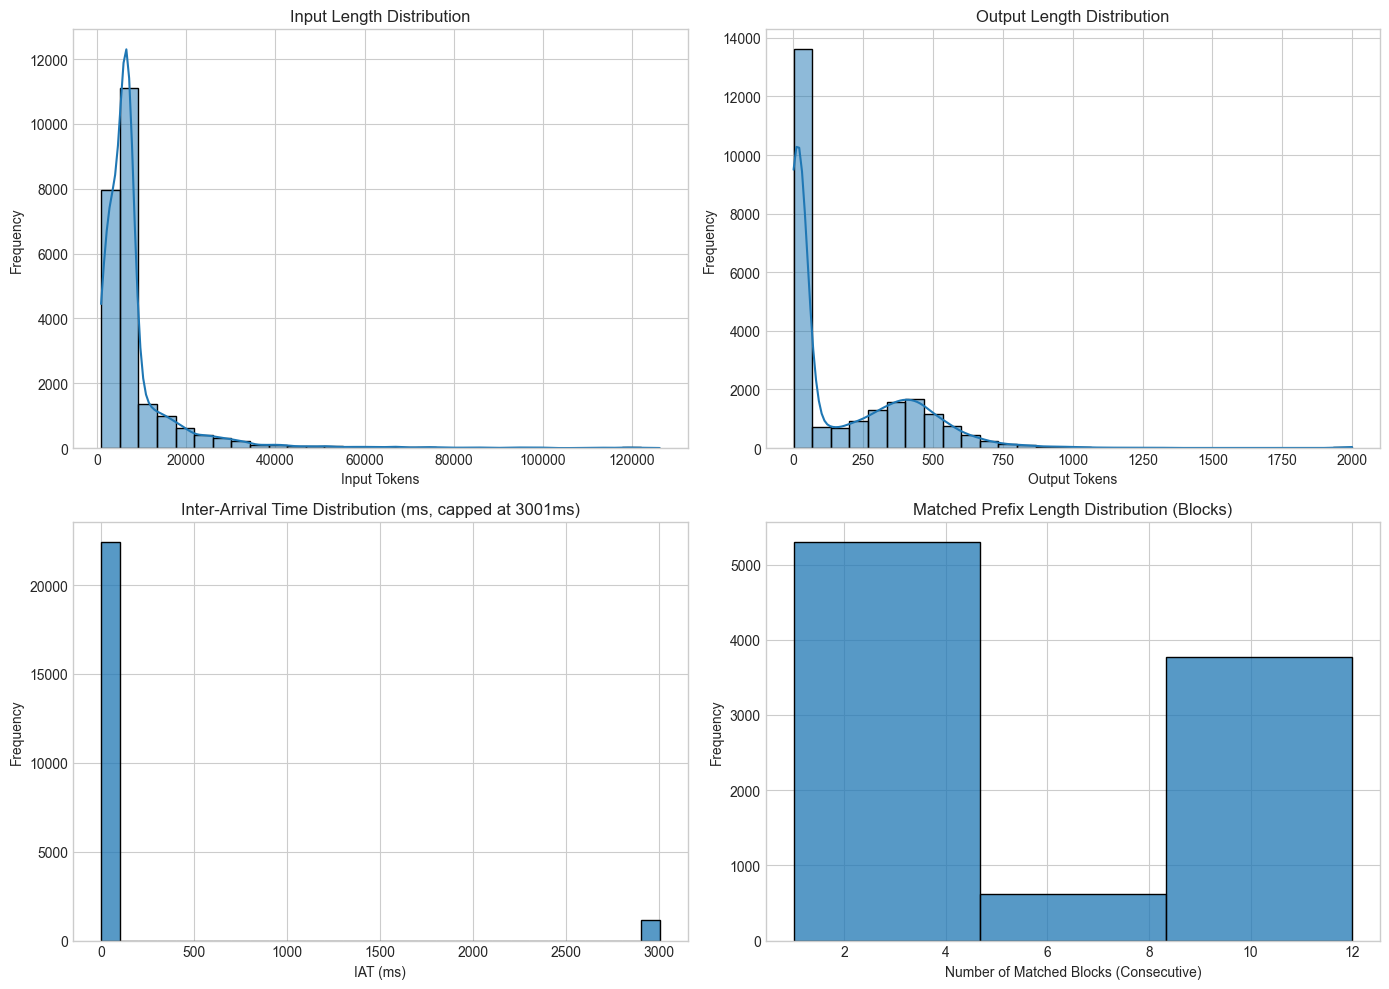

In [9]:
if df.empty:
    print("DataFrame is empty, skipping visualization.")
else:
    try:
        plt.style.use('seaborn-v0_8-whitegrid') # Use a seaborn style
        plt.figure(figsize=(14, 10))

        # Input Length
        plt.subplot(2, 2, 1)
        sns.histplot(df['input_length'], kde=True, bins=30)
        plt.title('Input Length Distribution')
        plt.xlabel('Input Tokens')
        plt.ylabel('Frequency')

        # Output Length
        plt.subplot(2, 2, 2)
        sns.histplot(df['output_length'], kde=True, bins=30)
        plt.title('Output Length Distribution')
        plt.xlabel('Output Tokens')
        plt.ylabel('Frequency')

        # Inter-Arrival Time
        plt.subplot(2, 2, 3)
        # Plot IAT, maybe excluding the first 0 and extreme outliers for clarity
        iat_plot_data = df['iat_ms'][1:] # Exclude first 0 IAT
        if not iat_plot_data.empty:
            # Cap outliers for better visualization, e.g., at 99th percentile
            max_iat_plot = np.percentile(iat_plot_data.dropna(), 99) if len(iat_plot_data.dropna()) > 0 else iat_plot_data.max()
            sns.histplot(iat_plot_data[iat_plot_data <= max_iat_plot], kde=False, bins=30) # Use kde=False if too few points
            plt.title(f'Inter-Arrival Time Distribution (ms, capped at {max_iat_plot:.0f}ms)')
            plt.xlabel('IAT (ms)')
            plt.ylabel('Frequency')
        else:
             plt.title('Inter-Arrival Time Distribution (ms)')
             plt.text(0.5, 0.5, 'Not enough data for IAT plot', ha='center', va='center')
        
        # Matched Prefix Length (Consecutive)
        plt.subplot(2, 2, 4)
        requests_with_match = df[df['prefix_match_blocks'] > 0]
        if not requests_with_match.empty:
            sns.histplot(requests_with_match['prefix_match_blocks'], kde=False, bins=max(1, min(30, requests_with_match['prefix_match_blocks'].nunique()))) # Adjust bins
            plt.title('Matched Prefix Length Distribution (Blocks)')
            plt.xlabel('Number of Matched Blocks (Consecutive)')
            plt.ylabel('Frequency')
        else:
            plt.text(0.5, 0.5, 'No Consecutive Matches Found', ha='center', va='center')
            plt.title('Matched Prefix Length Distribution (Blocks)')

        plt.tight_layout()
        plt.show()

    except ImportError:
        print("\nPlease install matplotlib and seaborn (`pip install matplotlib seaborn`) to see visualizations.")
    except Exception as e:
        print(f"An error occurred during plotting: {e}")

In [10]:
# Create a formatter function that converts thousands to 'k'
def thousands_formatter(x, pos):
    if x == 0:
        return '0'
    elif x < 1000:
        return str(int(x))
    elif x == 65536:
        return '64k'
    elif x == 131072:
        return '128k'
    else:
        return f'{int(x/1000)}k'

FONT:  Sans Serif


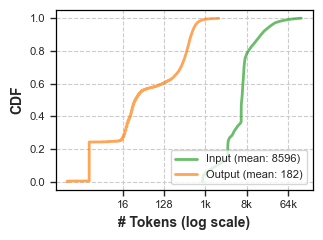

Combined styled CDF plot saved to output/combined_length_cdf_logscale_styled.pdf


In [11]:
plt.rcParams.update({'font.size': 10})
plt.rcParams.update({'font.family': FONT})

print("FONT: ", FONT)

# Create a figure optimized for single column in SOSP paper (typically ~3.33 inches wide)
fig, ax = plt.subplots(figsize=(3.33, 2.5))
line_width = 2

# Calculate input and output values and sort them for manual CDF plotting
input_values = np.sort(df['input_length'].values)
output_values = np.sort(df['output_length'].values)

# Create y-coordinates for CDF (0 to 1)
input_y = np.linspace(0, 1, len(input_values))
output_y = np.linspace(0, 1, len(output_values))

# Calculate means for the legend
input_mean = df['input_length'].mean()
output_mean = df['output_length'].mean()

# Plot Input Length CDF manually using ax.plot()
ax.plot(input_values, input_y, 
        color=COLORS[0],
        linewidth=line_width,
        label=f'Input (mean: {int(round(input_mean))})',
        alpha=OPACITY)

# Plot Output Length CDF manually using ax.plot()
ax.plot(output_values, output_y,
        color=COLORS[1],
        linewidth=line_width,
        label=f'Output (mean: {int(round(output_mean))})',
        alpha=OPACITY)

# --- Style Customization to Match Reference ---
# Set X-axis scale to logarithmic
ax.set_xscale('log')

# Configure major grid (matching reference style)
ax.grid(which='major', axis='both', linestyle='--', alpha=1.0)

# Set axis labels with bold style (matching reference)
ax.set_xlabel('# Tokens (log scale)', fontsize=10, fontweight='bold')
ax.set_ylabel('CDF', fontsize=10, fontweight='bold')

# Set specific log-scale x-ticks to match reference style
# Set the actual numeric values for your ticks
ax.set_xticks([16, 128, 1024, 8192, 65536])
# ax.xaxis.set_major_formatter(plt.ScalarFormatter())
ax.xaxis.set_major_formatter(ticker.FuncFormatter(thousands_formatter))

# Remove minor ticks that can appear with log scale
ax.tick_params(axis='both', which='minor', length=0)

# Configure major tick parameters
ax.tick_params(axis='both', which='major', labelsize=8, width=1, length=4)

# Set Y limits to match reference
ax.set_ylim(-0.05, 1.05)

# Ensure all spines are visible and black
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(0.9)

# Add legend with frame
legend = ax.legend(loc='lower right', fontsize=8, frameon=True)

# Apply tight layout
plt.tight_layout()

# Save the plot
plot_filename = "output/combined_length_cdf_logscale_styled.pdf"
plt.show()
plt.savefig(plot_filename, bbox_inches='tight')
print(f"Combined styled CDF plot saved to {plot_filename}")
plt.close()

## 6. Conclusion (Based on Sample)

Based *only* on the very small `trace_sample.jsonl`:

*   **Workload:** Characterized by very long input sequences and relatively short outputs.
*   **Arrival:** Variable, with some potential burstiness but also long gaps (needs more data).
*   **Caching Potential:**
    *   Direct consecutive request matching was rare in this sample.
    *   Individual block repetition (hot blocks) was also low.
    *   However, the *structure* for reuse exists (e.g., the last two requests shared a long prefix `[46, ..., 57]`).

**Overall:** This small sample hints at the long-context nature but doesn't fully demonstrate the high cache hit rates reported in the MOONCAKE paper (which likely arise from multi-turn interactions and system prompts repeating across many sessions in the full dataset).